# Dependence & Copula Analysis

Portfolio VaR estimated from a univariate return series (as in Notebook 02) ignores the **joint dependence structure** across assets. During stress periods, assets tend to co-move more strongly, making diversification less effective when it is most needed.

**Copula functions** separate the marginal distributions of individual assets from their dependence structure:

$$F(r_1, \ldots, r_n) = C(F_1(r_1), \ldots, F_n(r_n))$$

where $C: [0,1]^n \to [0,1]$ is the copula and $F_i$ are the marginal CDFs.

The **Gaussian copula** assumes the dependence structure is fully characterised by a linear correlation matrix $\Sigma$:

$$C^{Ga}(u_1, \ldots, u_n; \Sigma) = \Phi_\Sigma(\Phi^{-1}(u_1), \ldots, \Phi^{-1}(u_n))$$

where $\Phi^{-1}$ is the standard normal quantile function and $\Phi_\Sigma$ is the multivariate normal CDF with correlation $\Sigma$.

It is worth mention that the Gaussian copula has **zero tail dependence**, which means it underestimates the probability of simultaneous extreme losses. This was a central failure mechanism in the 2008 CDO crisis.

In this notebook, we will:
1. Fits marginal distributions per asset using empirical CDFs;
2. Estimates the Gaussian copula correlation matrix;
3. Compares copula structure across HMM regimes;
4. Simulates joint portfolio losses via Monte Carlo;
5. Quantifies diversification benefit and its regime-dependence.

In [17]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, t as t_dist
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

from IPython.display import display, Image as IPImage

warnings.filterwarnings('ignore')
np.random.seed(926)

ROOT = Path().resolve().parent
OUT_RETURNS = ROOT / 'data' / 'processed' / 'returns'
OUT_REGIMES = ROOT / 'data' / 'processed' / 'regimes'
OUT_RISK = ROOT / 'data' / 'processed' / 'risk_metrics'
OUT_COPULA = ROOT / 'data' / 'processed' / 'risk_metrics'

log_returns = pd.read_csv(OUT_RETURNS / 'log_returns.csv', index_col='date', parse_dates=True)
portfolio_return = pd.read_csv(OUT_RETURNS / 'portfolio_return.csv', index_col='date', parse_dates=True).squeeze()
regime_labels = pd.read_csv(OUT_REGIMES / 'regime_labels.csv', index_col='date', parse_dates=True)['regime']


common_idx = log_returns.index.intersection(regime_labels.index)
log_ret = log_returns.reindex(common_idx)
regime_aligned = regime_labels.reindex(common_idx)

## Marginal Transformation — Empirical CDF

We first transform each asset's returns to uniform marginals $u_i = F_i(r_i) \in [0,1]$ via the empirical CDF using the rank transformation (probability integral transform):

$$u_{i,t} = \frac{\text{rank}(r_{i,t})}{T + 1}$$

Dividing by $T+1$ rather than $T$ avoids boundary values of exactly 0 or 1, which would lead to infinite values in the subsequent normal quantile transformation $\Phi^{-1}(u_{i,t})$.

This non-parametric approach makes no assumption about the marginal distribution of each asset, which is consistentent with our finding in Notebook 01 that returns are non-normal.

In [9]:
T = len(log_ret)

uniform_marginals = log_ret.rank() / (T + 1)

# Check all values in (0,1)
assert (uniform_marginals > 0).all().all(), 'Values <= 0 found'
assert (uniform_marginals < 1).all().all(), 'Values >= 1 found'

print(f'Uniform marginals shape : {uniform_marginals.shape}')
print(f'\nSample statistics (should be ~ Uniform[0,1]):')
print(f' Mean : {uniform_marginals.mean().mean():.4f} ')
print(f' Std  : {uniform_marginals.std().mean():.4f}')
print(f' Min  : {uniform_marginals.min().min():.6f}')
print(f' Max  : {uniform_marginals.max().max():.6f}')

# Transform to standard normal scores for Gaussian copula
normal_scores = uniform_marginals.apply(lambda col: norm.ppf(col))

print(f'\nNormal scores shape : {normal_scores.shape}')
print(f'Normal scores stats (should be ~ N(0,1)):')
print(f' Mean : {normal_scores.mean().mean():.4f}')
print(f' Std  : {normal_scores.std().mean():.4f}')
print(f' Min  : {normal_scores.min().min():.3f}')
print(f' Max  : {normal_scores.max().max():.3f}')

Uniform marginals shape : (5262, 12)

Sample statistics (should be ~ Uniform[0,1]):
 Mean : 0.5000 
 Std  : 0.2886
 Min  : 0.000190
 Max  : 0.999810

Normal scores shape : (5262, 12)
Normal scores stats (should be ~ N(0,1)):
 Mean : 0.0000
 Std  : 0.9987
 Min  : -3.554
 Max  : 3.554


The empirical CDF transformation successfully maps asset returns to approximately Uniform(0,1) marginals, with sample moments closely matching theoretical values (mean = 0.50, standard deviation = 0.289). Applying the inverse normal transformation produces latent Gaussian scores with mean approximately zero and unit variance, confirming that the data are suitable for Gaussian copula estimation. The transformed variables preserve the rank dependence structure of the original returns while removing assumptions about marginal distributions, allowing dependence modelling to be separated from marginal behaviour.

## Gaussian Copula — Full Sample

The Gaussian copula correlation matrix $\Sigma$ is estimated as the **Pearson correlation matrix of the normal scores**:

$$\hat{\Sigma} = \frac{1}{T-1} Z^T Z$$

where $Z$ is the $T \times n$ matrix of normal scores. This is the maximum likelihood estimator for the Gaussian copula correlation matrix.

We visualise $\hat{\Sigma}$ as a heatmap and compute the average pairwise copula correlation as a summary statistic.

In [10]:
copula_corr_full = normal_scores.corr()

print('Full-sample Gaussian copula correlation matrix:')
print(f' Shape : {copula_corr_full.shape}')

n  = N_ASSETS
off_diag = copula_corr_full.values[np.triu_indices(n, k=1)]
print(f'  Mean corr : {off_diag.mean():.4f}')
print(f'  Std corr : {off_diag.std():.4f}')
print(f'  Min corr : {off_diag.min():.4f}')
print(f'  Max corr : {off_diag.max():.4f}')

fig = go.Figure(go.Heatmap(
    z = copula_corr_full.values,
    x = TICKERS,
    y = TICKERS,
    colorscale  = 'RdYlGn',
    zmin = -1, zmax=1,
    text = copula_corr_full.round(2).values,
    texttemplate = '%{text}',
    textfont = dict(size=9),
    colorbar = dict(title='Correlation'),
))

fig.update_layout(
    title  = 'Gaussian Copula Correlation Matrix — Full Sample (2005-2025)',
    height = 550,
    width  = 650,
)
fig.show()

Full-sample Gaussian copula correlation matrix:
 Shape : (12, 12)
  Mean corr : 0.4190
  Std corr : 0.1114
  Min corr : 0.2732
  Max corr : 0.8449


Full-sample Gaussian copula correlation matrix:
 Shape : (12, 12)
  Mean corr : 0.4190
  Std corr : 0.1114
  Min corr : 0.2732
  Max corr : 0.8449


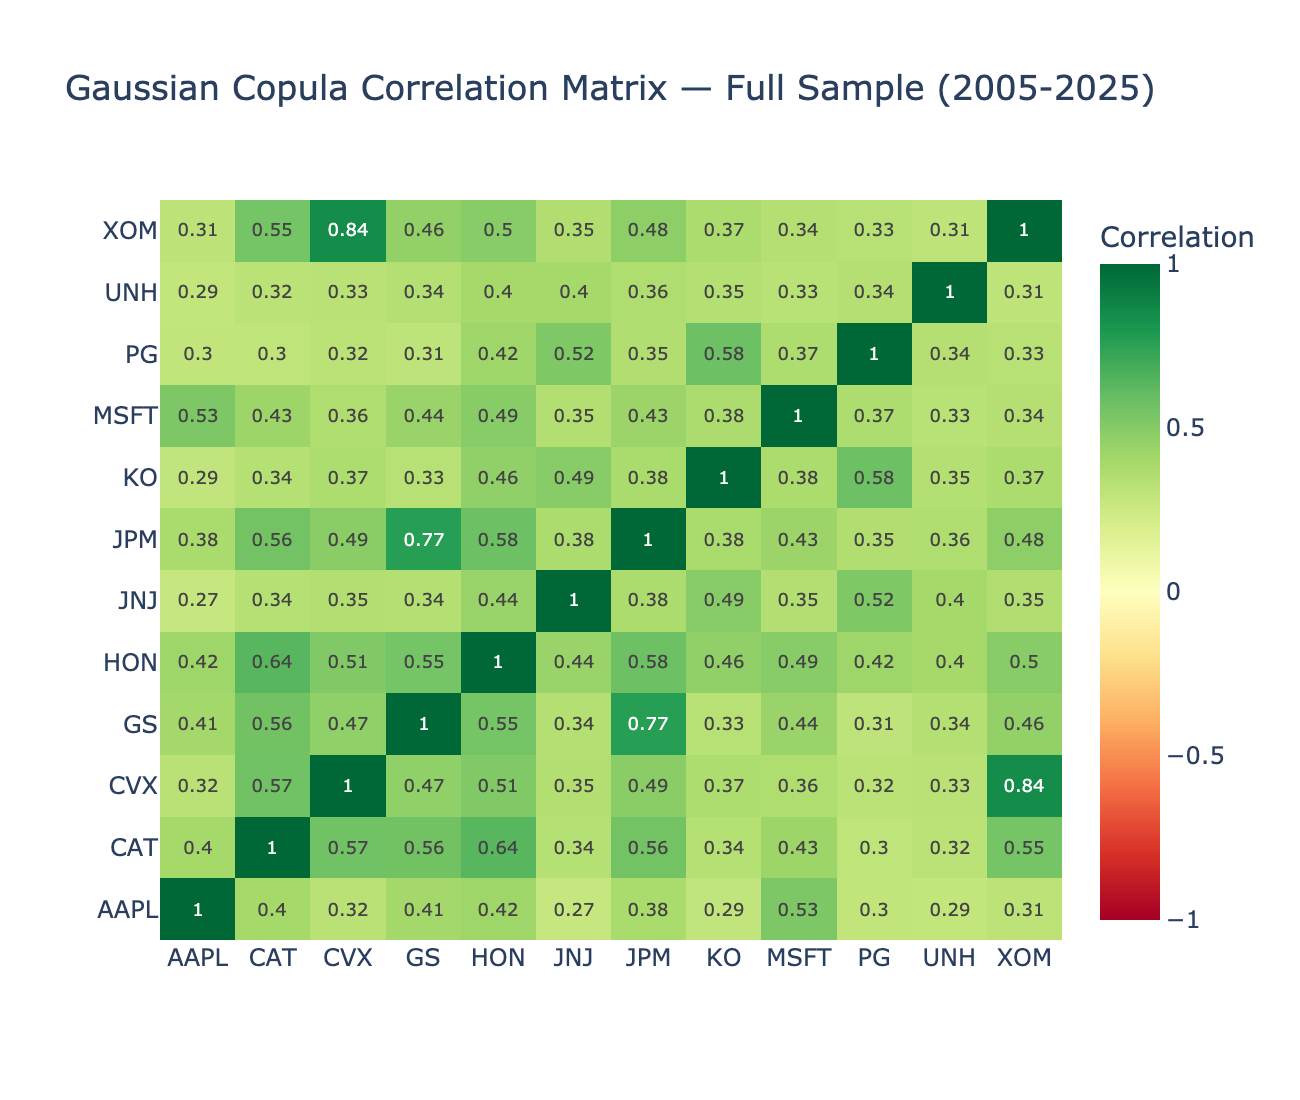

In [22]:
copula_corr_full = normal_scores.corr()

print('Full-sample Gaussian copula correlation matrix:')
print(f' Shape : {copula_corr_full.shape}')

n  = N_ASSETS
off_diag = copula_corr_full.values[np.triu_indices(n, k=1)]
print(f'  Mean corr : {off_diag.mean():.4f}')
print(f'  Std corr : {off_diag.std():.4f}')
print(f'  Min corr : {off_diag.min():.4f}')
print(f'  Max corr : {off_diag.max():.4f}')

FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

fig = go.Figure(go.Heatmap(
    z = copula_corr_full.values,
    x = TICKERS,
    y = TICKERS,
    colorscale = 'RdYlGn',
    zmin=-1, zmax=1,
    text = copula_corr_full.round(2).values,
    texttemplate = '%{text}',
    textfont = dict(size=9),
    colorbar = dict(title='Correlation'),
))
fig.update_layout(
    title  = 'Gaussian Copula Correlation Matrix — Full Sample (2005-2025)',
    height = 550,
    width  = 650,
)
fig.show() # Interactive Plotly

#  Static PNG (saved + displayed inline)
fig.write_image(str(FIGURES_DIR / '04_copula_corr_full.png'), scale=2)
display(IPImage(filename=str(FIGURES_DIR / '04_copula_corr_full.png'), width=650))